In [28]:
import numpy as np

import matplotlib.pyplot as plt
from cycler import cycler
from coffea import util
from coffea.processor import accumulate
import hist
import hist.intervals

from ttgamma.utils.plotting import (
    RebinHist,
    SetRangeHist,
    GroupBy,
    DictToHist,
    plotWithRatio,
    plotWithRatio_freq,
)

In [29]:
from save_to_root import outputMC, outputData

%store -r bf_params_freq
%store -r cov_freq


groupingCategory = {
    "NonPrompt": [3j, 4j],
    "MisID": [2j],
    "Prompt": [1j],
}

groupingFineCategory = {
    "Genuine Photon": [1j],
    "Misidentified Electron": [2j],
    "Hadronic Photon": [3j],
    "Hadronic Fake": [4j],
}

groupingMCDatasets = {
    "ZG": [
        "ZGamma_01J_5f_lowMass",
    ],
    "WG": [
        "WGamma",
    ],
    "other": [
        "TTbarPowheg_Dilepton",
        "TTbarPowheg_Semilept",
        "TTbarPowheg_Hadronic",
        "W2jets",
        "W3jets",
        "W4jets",
        "DYjetsM50",
        "ST_s_channel",
        "ST_tW_channel",
        "ST_tbarW_channel",
        "ST_tbar_channel",
        "ST_t_channel",
        "TTWtoLNu",
        "TTWtoQQ",
        "TTZtoLL",
        "GJets_HT200To400",
        "GJets_HT400To600",
        "GJets_HT600ToInf",
        "ZZ",
        "WZ",
        "WW",
        "TGJets",
    ],
    "ttgamma": [
        "TTGamma_Dilepton",
        "TTGamma_SingleLept",
        "TTGamma_Hadronic",
    ],
}

colors = [
    "#e15759",  # ttgamma
    "#59a14f",  # WG
    "#4e79a7",  # ZG
    "#bab0ab",  # other
    "#b07aa1",  # MisID
    "#76b7b2",  # NonPrompt
]

In [30]:
# Group MC histograms
# we want to sort by
'''
outputMC = {
    process: accumulate(outputMC_[ds] for ds in datasets)
    for process, datasets in groupingMCDatasets.items()
}


def getHisto(name):
    return DictToHist(
        {process: histos[name] for process, histos in outputMC.items()}, name="dataset"
    )


# Group data histograms
outputDataHist = accumulate([histo for key, histo in outputData_.items()])\
'''
s = hist.tag.Slicer()

In [31]:
# 1) First reproduce the grouped MC object from your script
outputMC_grouped = {
    process: accumulate(outputMC[ds] for ds in datasets)
    for process, datasets in groupingMCDatasets.items()
}
outputDataHist = accumulate([histo for key, histo in outputData.items()])

def getHisto(name):
    return DictToHist(
        {process: histos[name] for process, histos in outputMC_grouped.items()},
        name="dataset"
    )

# 2) Helper to build the grouped histogram exactly as in your workflow
def build_grouped_hist(name, lepFlavor=sum, rebin_spec=None, axis_range=None):
    """
    name: histogram name, e.g. 'photon_chIso', 'M3', 'photon_lepton_mass_3j0t'
    lepFlavor: sum, 'electron', or 'muon'
    rebin_spec: dict like {"M3": s[50j:550j+1:hist.rebin(4)]}
    axis_range: tuple like ("M3", 50, 550)
    """
    h = getHisto(name)

    # sum/select lepton flavor if that axis exists
    axis_names = [ax.name for ax in h.axes]
    if "lepFlavor" in axis_names:
        h = h[{"lepFlavor": lepFlavor}]

    # collapse fine category -> Prompt / MisID / NonPrompt
    if "category" in axis_names or "category" in [ax.name for ax in h.axes]:
        h = GroupBy(h, "category", "category", groupingCategory)

    # apply optional rebinning/slicing
    if rebin_spec is not None:
        h = h[rebin_spec]

    # apply optional range restriction
    if axis_range is not None:
        axis_name, xmin, xmax = axis_range
        h = SetRangeHist(h, axis_name, xmin, xmax)

    return h

# 3) Extract the six mutually exclusive fit components
def extract_components(h, systematic="nominal", method="frequentist"):
    comps = {
        "ttgamma":   h[{"dataset": "ttgamma", "category": "Prompt",    "systematic": systematic}],
        "WG":        h[{"dataset": "WG",      "category": "Prompt",    "systematic": systematic}],
        "ZG":        h[{"dataset": "ZG",      "category": "Prompt",    "systematic": systematic}],
        "other":     h[{"dataset": "other",   "category": "Prompt",    "systematic": systematic}],
        "MisID":     h[{"dataset": sum,       "category": "MisID",     "systematic": systematic}],
        "NonPrompt": h[{"dataset": sum,       "category": "NonPrompt", "systematic": systematic}],
    }
    # apply scale factors
    for name, hist in comps.items():
        if method == "frequentist":
            sf = bf_params_freq[name]
        comps[name] = hist * sf
    return comps

def extract_components_with_stat(h, systematic="nominal", method=None):
    comps = {
        "ttgamma":   h[{"dataset": "ttgamma", "category": "Prompt",    "systematic": systematic}],
        "WG":        h[{"dataset": "WG",      "category": "Prompt",    "systematic": systematic}],
        "ZG":        h[{"dataset": "ZG",      "category": "Prompt",    "systematic": systematic}],
        "other":     h[{"dataset": "other",   "category": "Prompt",    "systematic": systematic}],
        "MisID":     h[{"dataset": sum,       "category": "MisID",     "systematic": systematic}],
        "NonPrompt": h[{"dataset": sum,       "category": "NonPrompt", "systematic": systematic}],
    }

    if method == "frequentist":
        for name, hist in comps.items():
            comps[name] = hist * bf_params_freq[name]

    return comps

def build_freq_postfit_band(comps_unscaled, cov_freq):
    """
    comps_unscaled: dict of UNscaled component histograms with keys
        ttgamma, WG, ZG, other, MisID, NonPrompt

    cov_freq: covariance matrix from the fit, shape (7, 7) or (6, 6)

    Returns
    -------
    pred : np.ndarray
        postfit total prediction per bin
    pred_err : np.ndarray
        propagated fit uncertainty per bin
    """

    param_names = ["ttgamma", "WG", "ZG", "other", "MisID", "NonPrompt"]

    # central prediction
    pred = np.zeros_like(next(iter(comps_unscaled.values())).values(), dtype=float)

    # Jacobian matrix per bin:
    # J[j, i] = d mu_i / d a_j = template_j(bin i)
    J = []

    for name in param_names:
        template = np.asarray(comps_unscaled[name].values(), dtype=float)
        sf = bf_params_freq[name]
        pred += sf * template
        J.append(template)

    J = np.asarray(J)   # shape = (6, nbins)

    # use only the 6x6 block corresponding to the scale factors
    cov6 = np.asarray(cov_freq[:6, :6], dtype=float)

    # pred_var[i] = J[:,i]^T cov J[:,i]
    pred_var = np.einsum("ib,ij,jb->b", J, cov6, J)
    pred_var = np.clip(pred_var, 0.0, None)
    pred_err = np.sqrt(pred_var)

    return pred, pred_err

# 4) Plot overlay
def plot_components_overlay(
    comps,
    title="",
    normalize=False,
    logy=False,
    linewidth=2
):
    plt.figure(figsize=(8, 6))

    for label, h in comps.items():
        vals = h.values()
        edges = h.axes[0].edges
        centers = 0.5 * (edges[:-1] + edges[1:])

        y = vals.copy()
        if normalize:
            total = np.sum(y)
            if total > 0:
                y = y / total

        plt.step(centers, y, where="mid", label=label, linewidth=linewidth)

    plt.xlabel(h.axes[0].label if h.axes[0].label else h.axes[0].name)
    plt.ylabel("Normalized entries" if normalize else "Entries")
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5) Obtain numpy arrays from histograms (for both dict of hists and just hists)
def components_to_numpy(comps):
    """
    Convert dict of Hist objects into numpy arrays.

    Returns:
        yields_dict   : dict of np arrays (counts per bin)
        errors_dict   : dict of np arrays (stat uncertainties)
        bin_edges     : bin edges
    """

    yields_dict = {}
    errors_dict = {}

    # grab binning from the first histogram
    first_hist = next(iter(comps.values()))
    bin_edges = first_hist.axes[0].edges

    for name, h in comps.items():
        vals = h.values()
        vars_ = h.variances()

        yields_dict[name] = np.array(vals)
        errors_dict[name] = np.sqrt(vars_) if vars_ is not None else np.sqrt(vals)

    return yields_dict, errors_dict, bin_edges

def datahist_to_numpy(h):
    """
    Convert a Hist data histogram into numpy arrays.

    Returns
    -------
    data_vals : np.ndarray
        Observed counts per bin
    data_err  : np.ndarray
        Statistical uncertainties
    bin_edges : np.ndarray
        Bin edges
    """

    data_vals = np.array(h.values())
    variances = h.variances()

    if variances is not None:
        data_err = np.sqrt(variances)
    else:
        # Poisson assumption
        data_err = np.sqrt(data_vals)

    bin_edges = h.axes[0].edges

    return data_vals, data_err, bin_edges

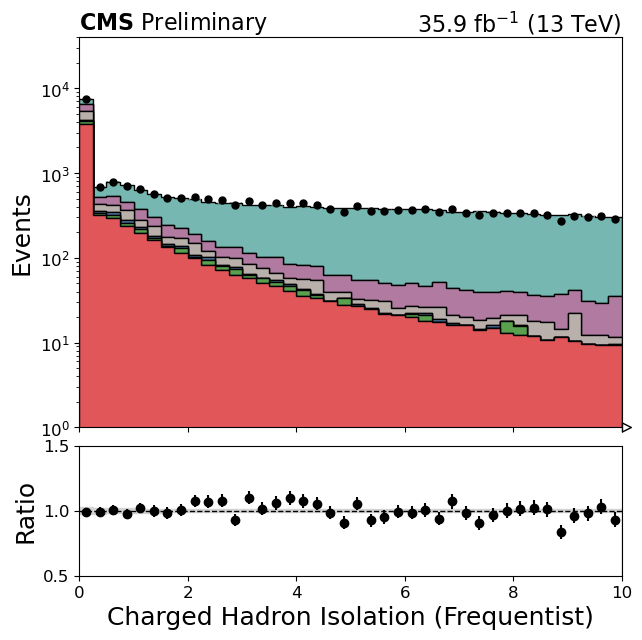

In [56]:
# Build histograms
h_chIso = build_grouped_hist(
    "photon_chIso",
    lepFlavor=sum,
    rebin_spec={"chIso": s[:: hist.rebin(5)]},
    axis_range=("chIso", 0, 10),
)

# Unscaled templates for uncertainty propagation
comps_chIso_unscaled = extract_components_with_stat(h_chIso, systematic="nominal", method=None)

# Scaled templates for stacked plot
comps_chIso = extract_components_with_stat(h_chIso, systematic="nominal", method="frequentist")
hComp_chIso = DictToHist(comps_chIso, name="dataset")

# Data histogram
hData_chIso = outputDataHist["photon_chIso"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_chIso_tmp = hData_chIso[{"chIso": s[:: hist.rebin(5)]}]
hData_chIso = SetRangeHist(hData_chIso_tmp, "chIso", 0, 10)

# Build postfit band from fit covariance
pred_chIso, pred_err_chIso = build_freq_postfit_band(comps_chIso_unscaled, cov_freq)

# Plot
fig, ax, rax = plotWithRatio_freq(
    hComp_chIso,
    hData_chIso,
    overlay="dataset",
    logY=True,
    leg="upper right",
    colors=colors,
    displeg=False,
    band_nominal=pred_chIso,
    band_err=pred_err_chIso,
)

rax.set_xlabel(r"Charged Hadron Isolation (Frequentist)")
plt.savefig("./Plots/freq_chIso_prop.png", dpi=300)

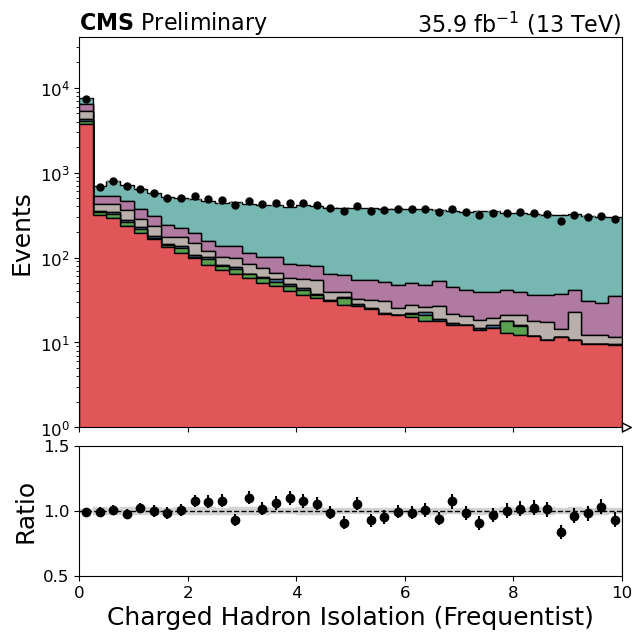

In [57]:
h_chIso = build_grouped_hist(
    "photon_chIso",
    lepFlavor=sum,
    rebin_spec={"chIso": s[:: hist.rebin(5)]},
    axis_range=("chIso", 0, 10),
)

comps_chIso = extract_components(h_chIso, systematic="nominal", method="frequentist")
hComp_chIso = DictToHist(comps_chIso, name="dataset")

hData_chIso = outputDataHist["photon_chIso"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_chIso_tmp = hData_chIso[{"chIso": s[:: hist.rebin(5)]}]
hData_chIso = SetRangeHist(hData_chIso_tmp, "chIso", 0, 10)

fig, ax, rax = plotWithRatio(hComp_chIso, hData_chIso, overlay="dataset", logY=True, leg="upper right", colors=colors, displeg=False)
rax.set_xlabel(r"Charged Hadron Isolation (Frequentist)")
plt.savefig("./Plots/freq_chIso.png", dpi=300)

In [58]:
#new_bins = np.array([1.1500000000000001, 2.5, 5, 9, 10])
#chIso_axis = hist.axis.Variable(new_bins, name="chIso", label="Charged Hadron Isolation")

#h_iso = build_grouped_hist("photon_chIso", lepFlavor=sum)
#h_iso = RebinHist(h_iso, chIso=chIso_axis)

#comps_iso = extract_components(h_iso, systematic="nominal")
'''plot_components_overlay(
    comps_chIso,
    title="photon_chIso components",
    normalize=False,   # shape comparison
    logy=True
)'''

'plot_components_overlay(\n    comps_chIso,\n    title="photon_chIso components",\n    normalize=False,   # shape comparison\n    logy=True\n)'

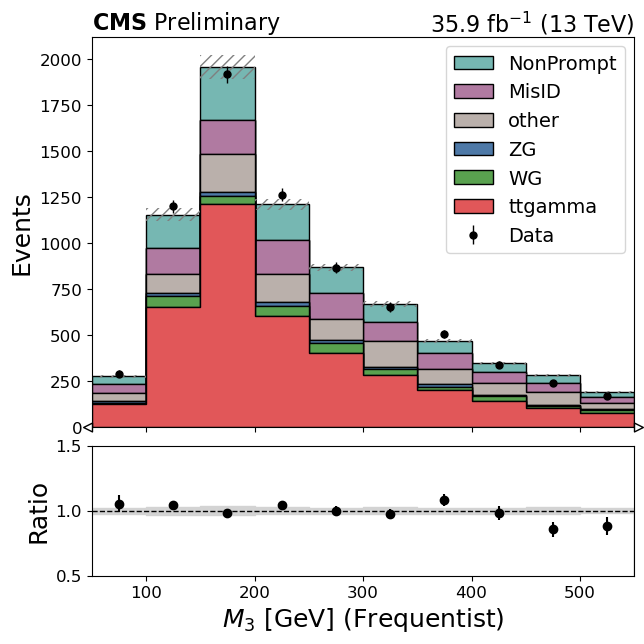

In [59]:
# Build histograms
h_m3 = build_grouped_hist(
    "M3",
    lepFlavor=sum,
    rebin_spec={"M3": s[50j:550j+1:hist.rebin(4)]},
    axis_range=("M3", 50, 550),
)

# Unscaled templates for uncertainty propagation
comps_m3_unscaled = extract_components_with_stat(h_m3, systematic="nominal", method=None)

# Scaled templates for stacked plot
comps_m3 = extract_components_with_stat(h_m3, systematic="nominal", method="frequentist")
hComp_m3 = DictToHist(comps_m3, name="dataset")

# Data histogram
hData_m3 = outputDataHist["M3"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_m3_tmp = hData_m3[{"M3": s[50j:550j+1:hist.rebin(4)]}]
hData_m3 = SetRangeHist(hData_m3_tmp, "M3", 50, 550)

# Build postfit band from fit covariance
pred_m3, pred_err_m3 = build_freq_postfit_band(comps_m3_unscaled, cov_freq)

# Plot
fig, ax, rax = plotWithRatio_freq(
    hComp_m3,
    hData_m3,
    overlay="dataset",
    logY=False,
    leg="upper right",
    colors=colors,
    displeg=True,
    band_nominal=pred_m3,
    band_err=pred_err_m3,
)

rax.set_xlabel(r"$M_3$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_m3_prop.png", dpi=300)

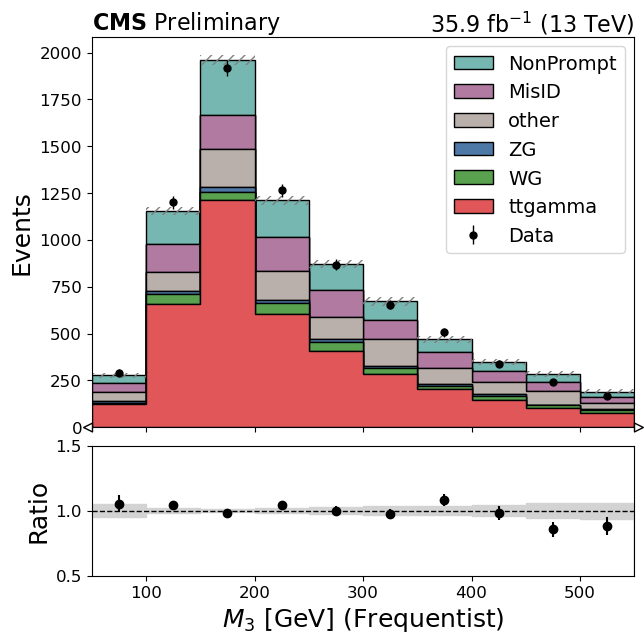

In [60]:
h_m3 = build_grouped_hist(
    "M3",
    lepFlavor=sum,
    rebin_spec={"M3": s[50j:550j+1:hist.rebin(4)]},
    axis_range=("M3", 50, 550),
)

comps_m3 = extract_components(h_m3, systematic="nominal", method="frequentist")
hComp_m3 = DictToHist(comps_m3, name="dataset")

hData_m3 = outputDataHist["M3"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_m3_tmp = hData_m3[{"M3": s[50j:550j+1:hist.rebin(4)]}]
hData_m3 = SetRangeHist(hData_m3_tmp, "M3", 50, 550)

fig, ax, rax = plotWithRatio(hComp_m3, hData_m3, overlay="dataset", leg="upper right", colors=colors, displeg=True)
rax.set_xlabel(r"$M_3$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_m3.png", dpi=300)


In [61]:
'''plot_components_overlay(
    comps_m3,
    title="M3 components",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_m3,\n    title="M3 components",\n    normalize=False,\n    logy=False\n)'

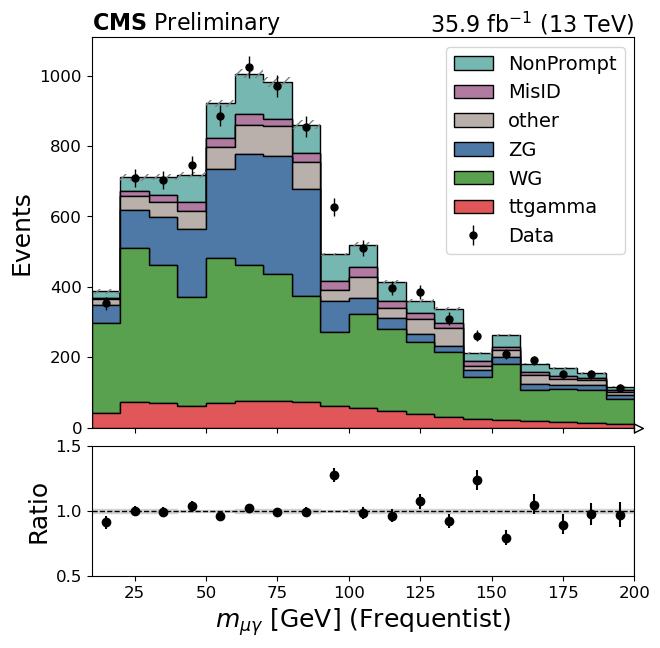

In [62]:
# Build histograms
h_mass_mu = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="muon",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)

# Unscaled templates for uncertainty propagation
comps_mass_mu_unscaled = extract_components_with_stat(h_mass_mu, systematic="nominal", method=None)

# Scaled templates for stacked plot
comps_mass_mu = extract_components_with_stat(h_mass_mu, systematic="nominal", method="frequentist")
hComp_mass_mu = DictToHist(comps_mass_mu, name="dataset")

# Data histogram
hData_mass_mu = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "muon", "category": sum, "systematic": sum}]
hData_mass_mu_tmp = hData_mass_mu[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_mu = SetRangeHist(hData_mass_mu_tmp, "mass", 10, 200)

# Build postfit band from fit covariance
pred_mass_mu, pred_err_mass_mu = build_freq_postfit_band(comps_mass_mu_unscaled, cov_freq)

# Plot
fig, ax, rax = plotWithRatio_freq(
    hComp_mass_mu,
    hData_mass_mu,
    overlay="dataset",
    logY=False,
    leg="upper right",
    colors=colors,
    displeg=True,
    band_nominal=pred_mass_mu,
    band_err=pred_err_mass_mu,
)

rax.set_xlabel(r"$m_{\mu \gamma}$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_mass_mu_prop.png", dpi=300)

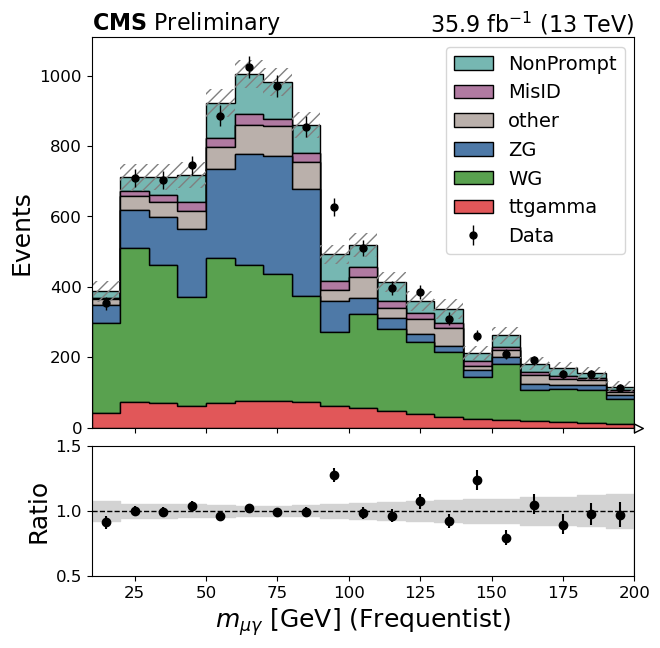

In [63]:
h_mass_mu = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="muon",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_mu = extract_components(h_mass_mu, systematic="nominal", method="frequentist")
hComp_mass_mu = DictToHist(comps_mass_mu, name="dataset")

hData_mass_mu = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "muon", "category": sum, "systematic": sum}]
hData_mass_mu_tmp = hData_mass_mu[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_mu = SetRangeHist(hData_mass_mu_tmp, "mass", 10, 200)

fig, ax, rax = plotWithRatio(hComp_mass_mu, hData_mass_mu, overlay="dataset", leg="upper right", colors=colors, displeg=True)
rax.set_xlabel(r"$m_{\mu \gamma}$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_mass_mu.png", dpi=300)


In [64]:
'''plot_components_overlay(
    comps_mass_mu,
    title="photon-lepton mass components (muon channel)",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_mass_mu,\n    title="photon-lepton mass components (muon channel)",\n    normalize=False,\n    logy=False\n)'

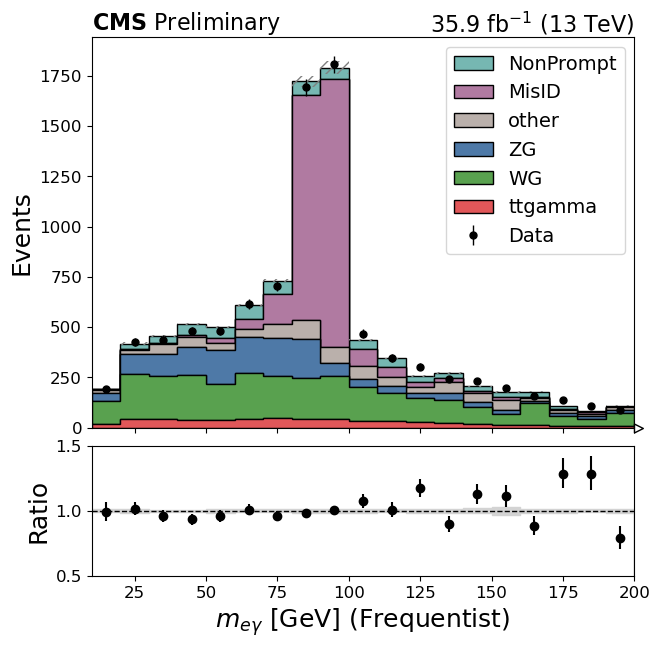

In [65]:
# Build histograms
h_mass_el = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="electron",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)

# Unscaled templates for uncertainty propagation
comps_mass_el_unscaled = extract_components_with_stat(h_mass_el, systematic="nominal", method=None)

# Scaled templates for stacked plot
comps_mass_el = extract_components_with_stat(h_mass_el, systematic="nominal", method="frequentist")
hComp_mass_el = DictToHist(comps_mass_el, name="dataset")

# Data histogram
hData_mass_el = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "electron", "category": sum, "systematic": sum}]
hData_mass_el_tmp = hData_mass_el[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_el = SetRangeHist(hData_mass_el_tmp, "mass", 10, 200)

# Build postfit band from fit covariance
pred_mass_el, pred_err_mass_el = build_freq_postfit_band(comps_mass_el_unscaled, cov_freq)

# Plot
fig, ax, rax = plotWithRatio_freq(
    hComp_mass_el,
    hData_mass_el,
    overlay="dataset",
    logY=False,
    leg="upper right",
    colors=colors,
    displeg=True,
    band_nominal=pred_mass_el,
    band_err=pred_err_mass_el,
)

rax.set_xlabel(r"$m_{e \gamma}$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_mass_el_prop.png", dpi=300)

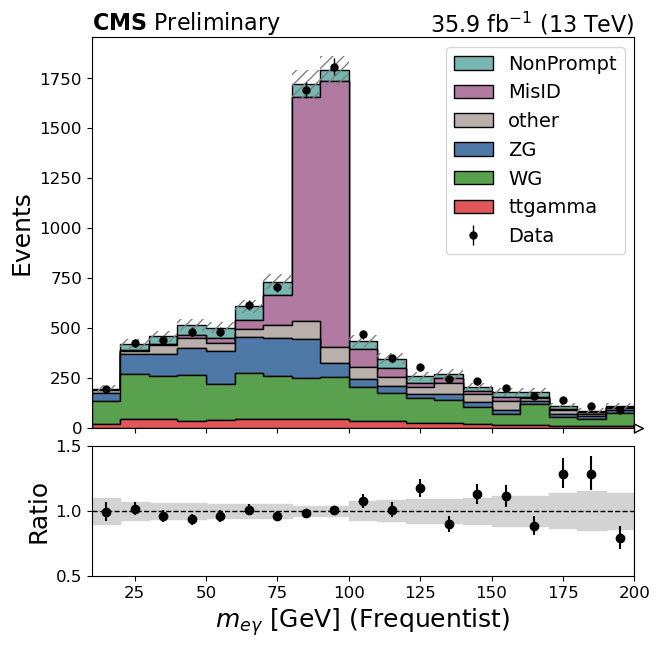

In [66]:
h_mass_el = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="electron",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_el = extract_components(h_mass_el, systematic="nominal", method="frequentist")
hComp_mass_el = DictToHist(comps_mass_el, name="dataset")

hData_mass_el = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "electron", "category": sum, "systematic": sum}]
hData_mass_el_tmp = hData_mass_el[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_el = SetRangeHist(hData_mass_el_tmp, "mass", 10, 200)

fig, ax, rax = plotWithRatio(hComp_mass_el, hData_mass_el, overlay="dataset", leg="upper right", colors=colors, displeg=True)
rax.set_xlabel(r"$m_{e \gamma}$ [GeV] (Frequentist)")
plt.savefig("./Plots/freq_mass_el.png", dpi=300)


In [67]:
'''plot_components_overlay(
    comps_mass_el,
    title="photon-lepton mass components (electron channel)",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_mass_el,\n    title="photon-lepton mass components (electron channel)",\n    normalize=False,\n    logy=False\n)'